In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_dataset_20000.csv")

In [3]:
df.head(5)

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [4]:
df.dtypes

age                       int64
gender                   object
marital_status           object
education_level          object
annual_income           float64
monthly_income          float64
employment_status        object
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose             object
interest_rate           float64
loan_term                 int64
installment             float64
grade_subgrade           object
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
delinquency_history       int64
public_records            int64
num_of_delinquencies      int64
loan_paid_back            int64
dtype: object

In [6]:
numeric = []
numeric_type = ['int64', 'float64']
for col in df.columns:
    if df[col].dtype in numeric_type:
        numeric.append(col)

In [7]:
# These are the numeric columns
numeric

['age',
 'annual_income',
 'monthly_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'loan_term',
 'installment',
 'num_of_open_accounts',
 'total_credit_limit',
 'current_balance',
 'delinquency_history',
 'public_records',
 'num_of_delinquencies',
 'loan_paid_back']

In [9]:
categorical = []
cate_type = ['object']
for col in df.columns:
    if df[col].dtype in cate_type:
        categorical.append(col)

categorical

['gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade']

In [10]:
# First numerical column -> age
print(df['age'].describe())

count    20000.000000
mean        48.027000
std         15.829352
min         21.000000
25%         35.000000
50%         48.000000
75%         62.000000
max         75.000000
Name: age, dtype: float64


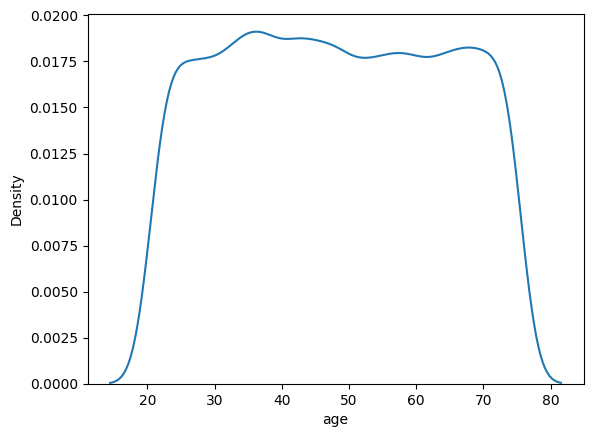

In [13]:
sns.kdeplot(data = df['age'])
plt.show()

Kinda skeptical of the distribution here so will have to plot the hist plot to get some more info probably

<Axes: >

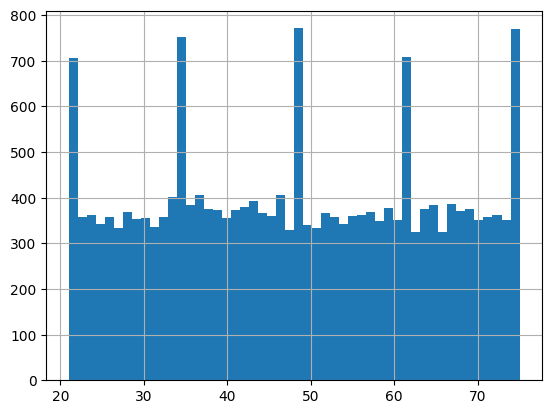

In [16]:
df['age'].hist(bins = 50)

# We can not have trust over the Kde plot since it is smoothening the spread Probability Mass into the region below 21 which is very misleading.

Inference from this histplot -> There are spikes in certain age groups which are maybe showing that at this stage of life, people do start taking more loans
or maybe it's just by chance that this is happening.

In [18]:
# Let's check for some null value inside the column of age
df['age'].isnull().sum()

0

Good thing this does not consist of any kind of null values.

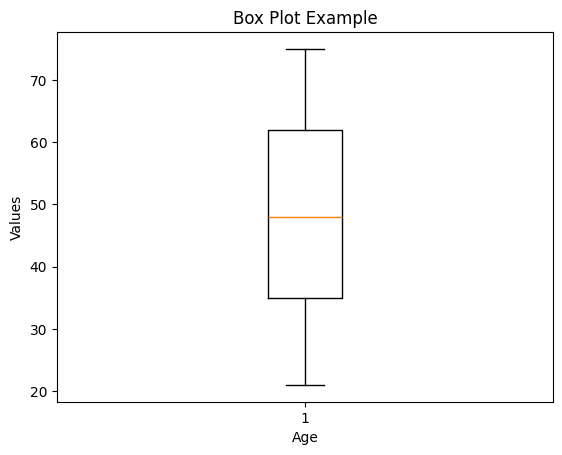

In [19]:
# Let's make a boxplot to analyze if there's going to see if there are any outliers present here or not

plt.boxplot(df['age'])

plt.xlabel('Age')
plt.ylabel('Values')
plt.title('Box Plot Example')
plt.show()

In [24]:
df.head(1)

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1


# Hooray, there are no such outliers present in this feature column.

<Axes: xlabel='loan_paid_back', ylabel='age'>

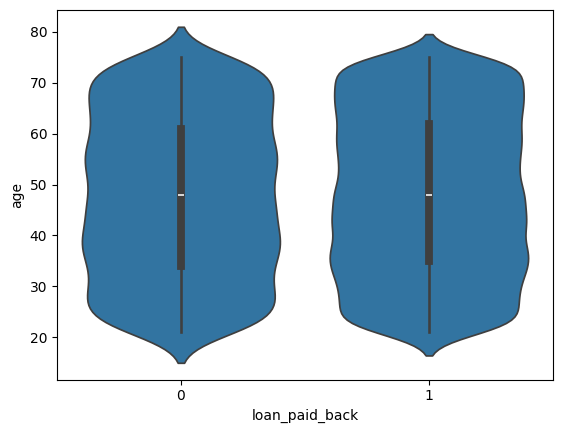

In [28]:
# Next step is to check what's the correlation of this column with the target column. 

"""
Since our target variable is a classification variable, either 0 or 1, we can use Violinplot for the same
"""

sns.violinplot(data = df, x = df['loan_paid_back'], y = df['age'])

In [ ]:
# The Violin plot shows there's not much correlation between the age column and the target so we are dropping it from the df

df